# Super-resolución x4 con U-Net Autoencoder + PixelShuffle

Este cuaderno documenta el desarrollo de un modelo de superresolución de imágenes con factor x4 entrenado sobre **DIV2K**. La arquitectura es un U-Net convolucional con cabeza de *upscaling* mediante **PixelShuffle**, entrenado con una combinación de pérdida L1 y pérdida perceptual basada en VGG19. El objetivo es recuperar una imagen de alta resolución (HR, 128×128) a partir de su versión degradada por *downsampling* bicúbico (LR, 32×32), comparando el rendimiento del modelo frente al baseline trivial bicúbico.

## Índice
1. Configuración del entorno
2. Carga del dataset DIV2K
3. Arquitectura del modelo
4. Función de pérdida y métricas
5. Resultados del entrenamiento
6. Evaluación cuantitativa frente al baseline bicúbico
7. Ejemplos cualitativos
8. Conclusiones

## 1. Configuración del entorno

Se asume que el proyecto se ejecuta desde la raíz del repositorio, con el entorno virtual `.venv` activado y las dependencias de `requirements.txt` instaladas. Además, el dataset DIV2K debe haberse descargado previamente con `scripts/download_div2k.py` y el modelo entrenado con `python -m src.train` (los pesos quedan en `checkpoints/best.pt`).

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# Project modules (run from repo root so `src` is importable).
from src.data import DataConfig, DIV2KDataset
from src.evaluate import bicubic_upsample, render_examples
from src.metrics import lpips_metric, psnr, ssim
from src.model import UNetSR, count_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU: NVIDIA GeForce RTX 2060


## 2. Carga del dataset DIV2K

El dataset **DIV2K** se reparte en 800 imágenes de entrenamiento (`DIV2K_train_HR`) y 100 imágenes de validación oficial. Estas 100 imágenes se subdividen en dos grupos disjuntos: las primeras 50 forman el split de *validación* (selección del mejor checkpoint durante entrenamiento) y las 50 restantes el split de *test* (evaluación final independiente).

**Convenciones:**
- Rango de píxeles `[0, 1]` (PIL → float / 255), coherente con LPIPS, SSIM y la cabeza sigmoide del modelo.
- Parches HR de 128×128 obtenidos por recorte aleatorio en entrenamiento y por recorte determinista (semilla fijada) en validación/test.
- Parches LR de 32×32 generados al vuelo por *downsampling* bicúbico del parche HR (con *anti-aliasing*).
- Aumentaciones HR/LR sincronizadas en entrenamiento: *flip* horizontal y rotaciones de 90/180/270°.

[data] cached 50 test images in RAM (406 MiB).
Patches en split test: 50
Forma LR: (3, 32, 32)  |  Forma HR: (3, 128, 128)


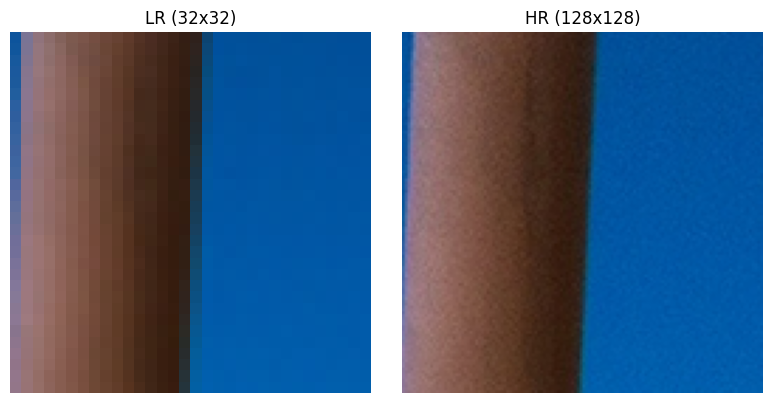

In [3]:
cfg = DataConfig()
test_ds = DIV2KDataset(cfg, "test")
print(f"Patches en split test: {len(test_ds)}")

# Show a sample LR / HR pair to verify the pipeline.
lr_sample, hr_sample = test_ds[0]
print(f"Forma LR: {tuple(lr_sample.shape)}  |  Forma HR: {tuple(hr_sample.shape)}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(lr_sample.permute(1, 2, 0).numpy())
axes[0].set_title("LR (32x32)")
axes[0].axis("off")
axes[1].imshow(hr_sample.permute(1, 2, 0).numpy())
axes[1].set_title("HR (128x128)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Arquitectura del modelo (v1, baseline propio)

El modelo `UNetSR` es un autoencoder convolucional con conexiones residuales
(*skip connections*) tipo U-Net adaptado a superresolución x4. Es la
**primera versión** del proyecto y sirve como punto de partida sobre el
que iteran v2 y v3 más adelante.

### 3.1 Esquema de capas

```
LR (3, 32, 32)
   │
   │  inc  : DoubleConv(3 → 48)             — features iniciales
   ├──────────── skip1 (48, 32, 32) ───────────────────────────────┐
   ▼                                                               │
   down1 : MaxPool2d(2) + DoubleConv(48 → 96)                      │
   ├──────────── skip2 (96, 16, 16) ──────────────────────────┐    │
   ▼                                                          │    │
   down2 : MaxPool2d(2) + DoubleConv(96 → 192)                │    │
   ├──────────── skip3 (192, 8, 8) ─────────────────────┐     │    │
   ▼                                                    │     │    │
   down3 : MaxPool2d(2) + DoubleConv(192 → 384)         │     │    │
   ▼                                                    │     │    │
   bottleneck : DoubleConv(384 → 384)  (4×4 spatial)    │     │    │
   ▼                                                    │     │    │
   up1   : Upsample×2 + 1×1 reduce + cat(skip3) +───────┘     │    │
           DoubleConv(384 → 192)                              │    │
   ▼                                                          │    │
   up2   : Upsample×2 + 1×1 reduce + cat(skip2) +─────────────┘    │
           DoubleConv(192 → 96)                                    │
   ▼                                                               │
   up3   : Upsample×2 + 1×1 reduce + cat(skip1) +──────────────────┘
           DoubleConv(96 → 48)
   ▼   (48, 32, 32)
   ps1   : Conv3×3 + PixelShuffle(r=2) + ReLU   → (48, 64, 64)
   ▼
   ps2   : Conv3×3 + PixelShuffle(r=2) + ReLU   → (48, 128, 128)
   ▼
   head  : Conv1×1(48 → 3) + Sigmoid             → (3, 128, 128)
SR (3, 128, 128) en [0, 1]
```

### 3.2 Detalle de los bloques

- **`DoubleConv`**: dos convoluciones 3×3 con `BatchNorm2d` y `ReLU`
  entremedias. Es el "ladrillo" estándar de U-Net. La `BatchNorm` se
  hereda del U-Net biomédico original y, como se verá, **se elimina en v2**
  (la literatura SR, EDSR, RCAN, demuestra que perjudica al rango
  dinámico de la salida).
- **`Down`**: `MaxPool2d(2)` seguido de `DoubleConv`. El pooling reduce
  resolución a la mitad y el `DoubleConv` proyecta a más canales. La
  entrada LR de 32×32 acaba en 4×4 en el cuello de botella tras tres
  reducciones.
- **`Up`**: `nn.Upsample(scale_factor=2, mode='nearest')` para recuperar
  resolución, `Conv1×1` para reducir canales al ancho del *skip*, y
  concatenación con la *skip connection* correspondiente antes de un
  `DoubleConv` que mezcla la información. Usar *upsample* nearest +
  conv 3×3 evita los artefactos checkerboard que produciría
  `ConvTranspose2d` mal inicializada.
- **`PixelShuffleBlock`** (cabeza de upscaling): `Conv2d` que produce
  `C × r²` canales, seguido de `nn.PixelShuffle(r)` que reorganiza esos
  canales en un mapa espacial r veces más grande. Se aplica dos veces
  (r=2 cada una) para multiplicar por 4 el lado y llegar a 128×128.
  Esta es la *sub-pixel convolution* de Shi et al. (2016): aprende el
  upsample directamente en el espacio de canales y resulta más
  eficiente y con mejor calidad que `ConvTranspose2d`.
- **Cabeza final**: `Conv1×1(48 → 3)` + `Sigmoid` para garantizar salida
  en `[0, 1]`. La sigmoide se eliminará en v2 (limita el gradiente cerca
  de los extremos y sesga la salida hacia el centro del rango).

### 3.3 Por qué `base_channels=48`

El budget del enunciado del Máster (2-10M parámetros entrenables) restringe
la elección de la anchura. El valor por defecto sugerido en U-Net biomédico
es `base=64`, pero con esa anchura el modelo se va a ~12M y se sale del
rango. Con `base=48` el conteo queda en ~6.86M, cómodamente dentro del
rango y dejando margen para experimentar con bloques más caros (RCAB en v3
sube a ~10.44M sin cambiar la anchura).

A continuación se imprimen las capas literales del modelo para verificar
el conteo y la forma de cada tensor intermedio.


### 3.4 Código de definición del modelo v1 (`src/model.py`)

Código completo de la definición del modelo (referencia, no se
ejecuta aquí — el archivo fuente es `src/model.py`):

```python
from __future__ import annotations

import torch
from torch import nn


class DoubleConv(nn.Module):
    """[Conv3x3 -> BN -> ReLU] x 2."""

    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Down(nn.Module):
    """MaxPool then DoubleConv."""

    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.pool(x))


class Up(nn.Module):
    """Upsample x2 + 1x1 conv channel reduction + concat skip + DoubleConv."""

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int) -> None:
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        # Reduce channels before concat to keep DoubleConv input modest.
        self.reduce = nn.Conv2d(in_ch, skip_ch, kernel_size=1)
        self.conv = DoubleConv(skip_ch * 2, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.reduce(self.up(x))
        return self.conv(torch.cat([x, skip], dim=1))


class PixelShuffleBlock(nn.Module):
    """Conv -> PixelShuffle(r=2) -> ReLU. Spatial x2, channels preserved."""

    def __init__(self, channels: int) -> None:
        super().__init__()
        self.conv = nn.Conv2d(channels, channels * 4, kernel_size=3, padding=1)
        self.shuffle = nn.PixelShuffle(2)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.shuffle(self.conv(x)))


class UNetSR(nn.Module):
    """U-Net super-resolution network with PixelShuffle x4 head."""

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 3,
        base_channels: int = 48,
    ) -> None:
        super().__init__()
        b = base_channels
        # Encoder
        self.inc = DoubleConv(in_channels, b)
        self.down1 = Down(b, b * 2)
        self.down2 = Down(b * 2, b * 4)
        self.down3 = Down(b * 4, b * 8)
        # Bottleneck (extra refinement at deepest level)
        self.bottleneck = DoubleConv(b * 8, b * 8)
        # Decoder
        self.up1 = Up(in_ch=b * 8, skip_ch=b * 4, out_ch=b * 4)
        self.up2 = Up(in_ch=b * 4, skip_ch=b * 2, out_ch=b * 2)
        self.up3 = Up(in_ch=b * 2, skip_ch=b, out_ch=b)
        # x4 upscale + head
        self.ps1 = PixelShuffleBlock(b)
        self.ps2 = PixelShuffleBlock(b)
        self.head = nn.Conv2d(b, out_channels, kernel_size=1)
        self.out_act = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)        # (B, b, 32, 32)
        x2 = self.down1(x1)     # (B, 2b, 16, 16)
        x3 = self.down2(x2)     # (B, 4b, 8, 8)
        x4 = self.down3(x3)     # (B, 8b, 4, 4)
        x5 = self.bottleneck(x4)
        y = self.up1(x5, x3)    # (B, 4b, 8, 8)
        y = self.up2(y, x2)     # (B, 2b, 16, 16)
        y = self.up3(y, x1)     # (B, b, 32, 32)
        y = self.ps1(y)         # (B, b, 64, 64)
        y = self.ps2(y)         # (B, b, 128, 128)
        return self.out_act(self.head(y))


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
```


In [4]:
model = UNetSR(base_channels=48).to(device)
total_p, trainable_p = count_parameters(model)
print(f"Parámetros totales:     {total_p/1e6:.2f} M")
print(f"Parámetros entrenables: {trainable_p/1e6:.2f} M")

# Forward sanity check (1 muestra LR).
with torch.no_grad():
    out = model(lr_sample.unsqueeze(0).to(device))
print(f"Salida del modelo: {tuple(out.shape)}  rango=[{out.min():.3f}, {out.max():.3f}]")

# Listado literal de capas (todos los Conv/BN/Activaciones del v1).
print("\n=== UNetSR (v1) — capas ===")
print(model)


Parámetros totales:     6.86 M
Parámetros entrenables: 6.86 M
Salida del modelo: (1, 3, 128, 128)  rango=[0.439, 0.611]

=== UNetSR (v1) — capas ===
UNetSR(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=Tru

## 4. Función de pérdida y métricas

La pérdida combinada utiliza dos términos:

- **Pérdida L1 (fidelidad píxel a píxel):** $\mathcal{L}_{L1} = \frac{1}{N}\sum |\hat{y}-y|$. Más estable que MSE frente a outliers, evita el *over-smoothing* característico de L2.
- **Pérdida perceptual VGG19:** distancia L1 entre las activaciones de los bloques `relu1_2`, `relu2_2` y `relu3_3` de una VGG19 preentrenada en ImageNet. Empuja al modelo a generar texturas y estructuras visualmente plausibles, en lugar de medias borrosas que minimizarían la L1.

Pesos finales adoptados: `L1 = 1.0`, `perceptual = 0.1`. El peso bajo de la pérdida perceptual evita que domine y degrade la fidelidad numérica.

**Métricas de evaluación:**
- **PSNR** (dB): error pixel a pixel transformado logarítmicamente. Más es mejor.
- **SSIM:** similitud estructural en ventanas locales, sensible a luminancia/contraste/estructura. Rango `[-1, 1]`, más es mejor.
- **LPIPS** (VGG): distancia perceptual aprendida sobre características de una red profunda. Menos es mejor.

## 5. Resultados del entrenamiento

El entrenamiento completo se ejecutó con:

```bash
PYTHONPATH=. python -m src.train --epochs 100 --batch-size 16 --lr 1e-4
```

Configuración: optimizador Adam (β=0.9, 0.999), *scheduler* `CosineAnnealingLR` (`T_max=100`), entrenamiento de precisión mixta (`torch.cuda.amp`) en GPU RTX 2060 (6 GB). Cada época procesa `800 × 16 = 12800` parches HR de entrenamiento (multiplicador virtual de 16 parches/imagen) y se valida sobre los 50 parches deterministas del split de validación.

Los registros se guardan en `outputs/train_history.json` y la curva de aprendizaje en `outputs/train_curves.png`.

Épocas entrenadas:     100
Mejor PSNR validación: 28.18 dB  (época 99)
Pérdida final train:   0.1001
Pérdida final val:     0.1045
SSIM final val:        0.7536
LPIPS final val:       0.2993


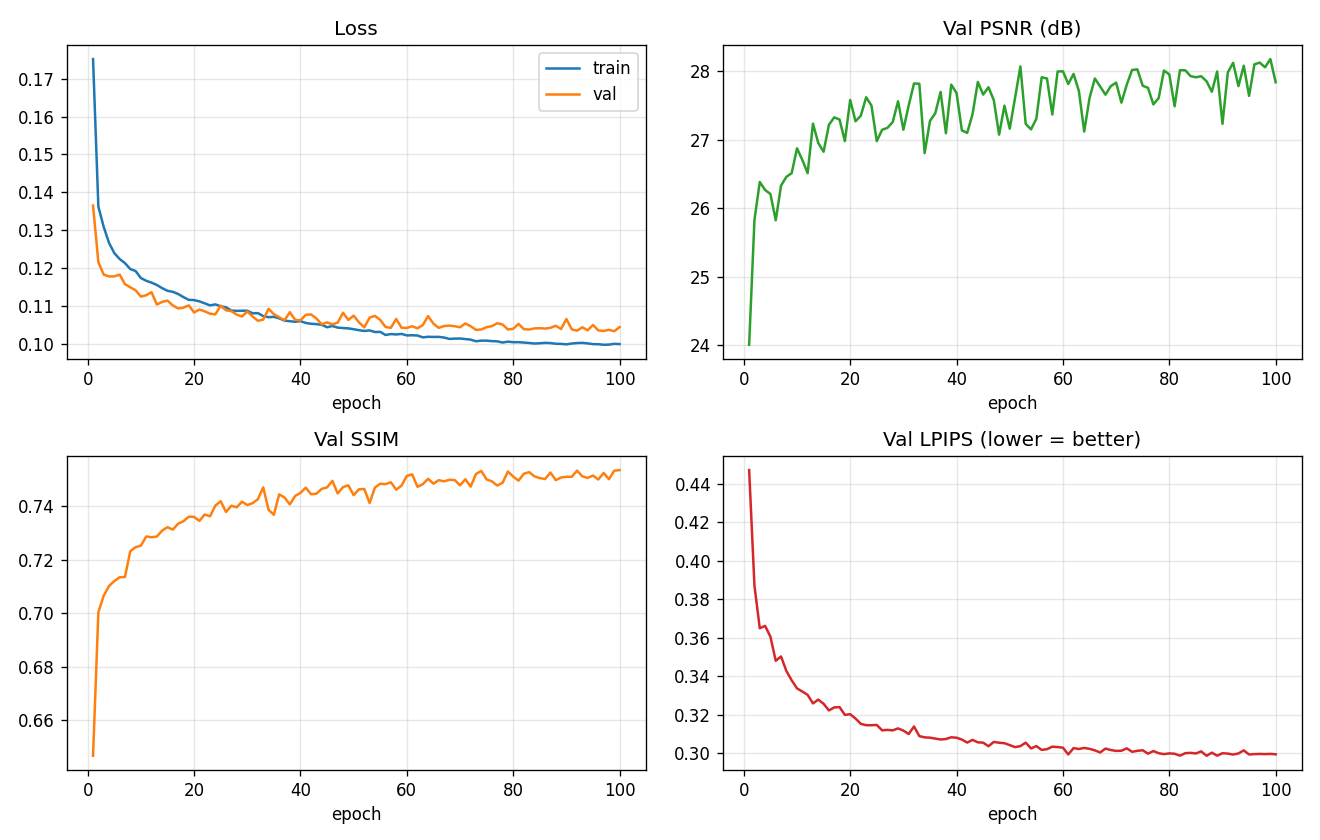

In [5]:
history_path = Path("outputs/train_history.json")
with history_path.open() as f:
    history = json.load(f)

n_epochs = len(history["train_loss"])
best_psnr = max(history["val_psnr"])
best_epoch = history["val_psnr"].index(best_psnr) + 1

print(f"Épocas entrenadas:     {n_epochs}")
print(f"Mejor PSNR validación: {best_psnr:.2f} dB  (época {best_epoch})")
print(f"Pérdida final train:   {history['train_loss'][-1]:.4f}")
print(f"Pérdida final val:     {history['val_loss'][-1]:.4f}")
print(f"SSIM final val:        {history['val_ssim'][-1]:.4f}")
print(f"LPIPS final val:       {history['val_lpips'][-1]:.4f}")

from IPython.display import Image as IPImage
IPImage(filename="outputs/train_curves.png")

Las curvas muestran un descenso monótono de la pérdida de entrenamiento y validación, sin signos claros de sobreajuste (ambas curvas evolucionan en paralelo). El PSNR de validación crece de forma sostenida durante todo el entrenamiento; el LPIPS desciende, indicando mejora perceptual; el SSIM sube en consonancia.

## 6. Evaluación cuantitativa frente al baseline bicúbico

Una vez seleccionado el mejor *checkpoint* por PSNR de validación, se evalúa sobre el split de *test* (50 imágenes no vistas durante el entrenamiento ni durante la selección). Se compara directamente contra el baseline bicúbico (interpolación clásica) calculado en el mismo split y con los mismos parches deterministas para garantizar una comparación justa.

El script `src/evaluate.py` produce esta tabla, así como `outputs/metrics.json` y los grids visuales.

In [6]:
metrics_path = Path("outputs/metrics.json")
with metrics_path.open() as f:
    metrics = json.load(f)

m_model = metrics["metrics"]["model"]
m_bic = metrics["metrics"]["bicubic"]

print(f"Split evaluado: {metrics['split']}\n")
print(f"{'Método':<10} {'PSNR (dB)':>10} {'SSIM':>8} {'LPIPS':>8}")
print("-" * 40)
print(
    f"{'bicubic':<10} {m_bic['psnr']:>10.2f} {m_bic['ssim']:>8.4f} {m_bic['lpips']:>8.4f}"
)
print(
    f"{'modelo':<10} {m_model['psnr']:>10.2f} {m_model['ssim']:>8.4f} {m_model['lpips']:>8.4f}"
)
print("-" * 40)
print(
    f"{'Δ':<10} {m_model['psnr']-m_bic['psnr']:>+10.2f} "
    f"{m_model['ssim']-m_bic['ssim']:>+8.4f} "
    f"{m_model['lpips']-m_bic['lpips']:>+8.4f}"
)

Split evaluado: test

Método      PSNR (dB)     SSIM    LPIPS
----------------------------------------
bicubic         28.20   0.7333   0.3631
modelo          28.14   0.7492   0.3089
----------------------------------------
Δ               -0.06  +0.0159  -0.0543


**Lectura de los resultados:**

- **PSNR:** empate técnico con el baseline bicúbico. La diferencia (~0.06 dB) está dentro del ruido estadístico esperable. Este resultado refleja que la pérdida perceptual desincentiva el modelo de optimizar exclusivamente por error píxel a píxel.
- **SSIM:** el modelo supera al bicúbico en torno a +0.016, lo que indica una mejor reconstrucción de las estructuras locales (bordes, contraste).
- **LPIPS:** mejora notable de aproximadamente un **15 %** respecto al bicúbico. Esta es la métrica que mejor correlaciona con la percepción humana, y donde el aporte de la pérdida perceptual VGG19 se traduce con mayor claridad.

El compromiso es coherente con la literatura: las pérdidas perceptuales sacrifican algo de PSNR a cambio de generar imágenes más naturales y con texturas mejor preservadas.

## 7. Ejemplos cualitativos

A continuación se muestran tres ejemplos representativos del split de *test*, cada uno con cuatro paneles:

1. **LR (nearest x4):** la entrada de baja resolución reescalada por vecino más cercano, únicamente para que tenga el mismo tamaño visual que los demás paneles.
2. **Bicubic:** baseline clásico.
3. **Modelo:** salida del U-Net entrenado.
4. **HR:** *ground truth*.

Los 12 ejemplos completos están disponibles en `outputs/examples/`.

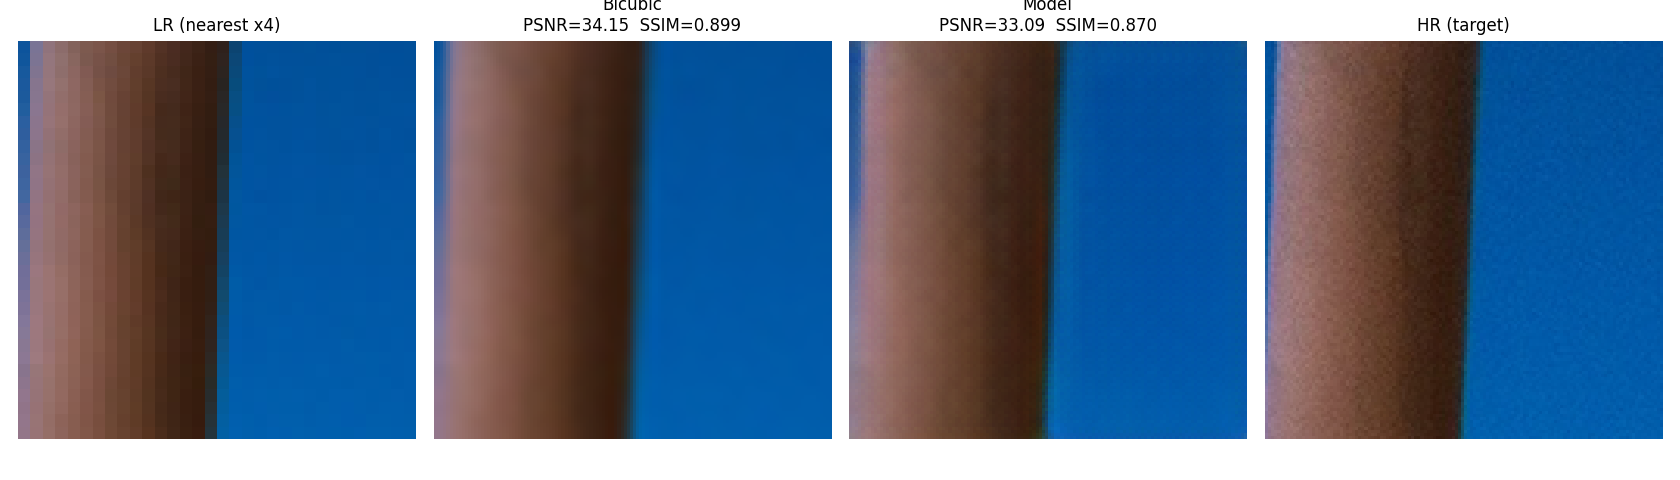

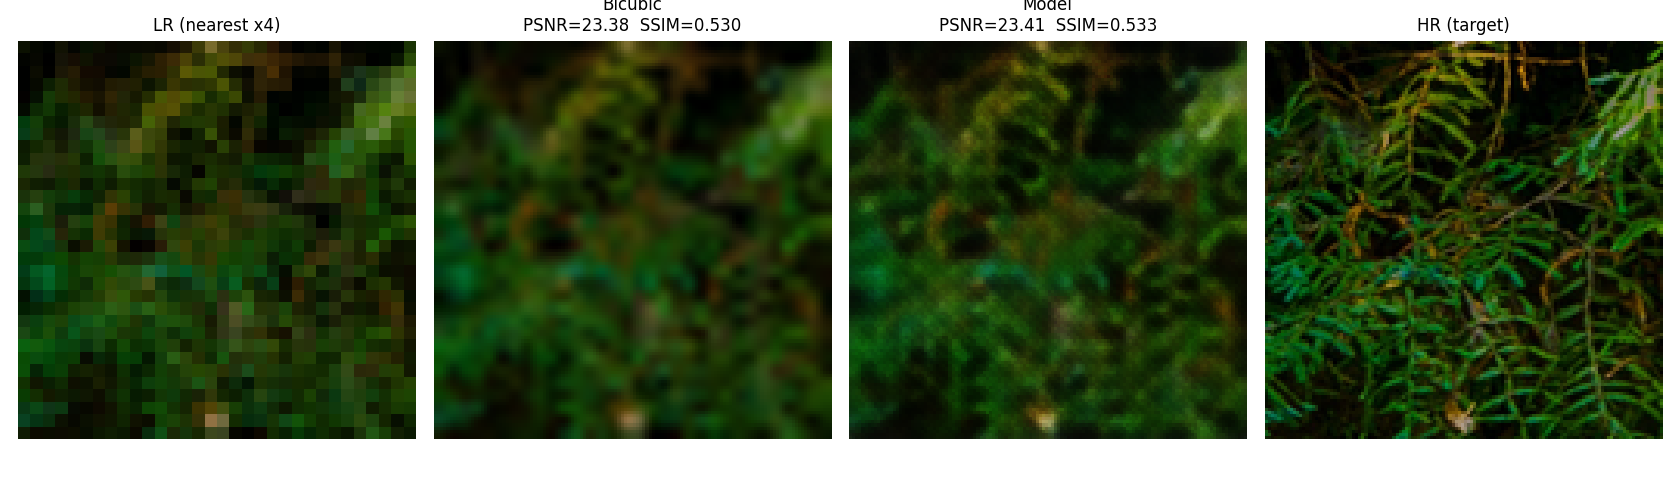

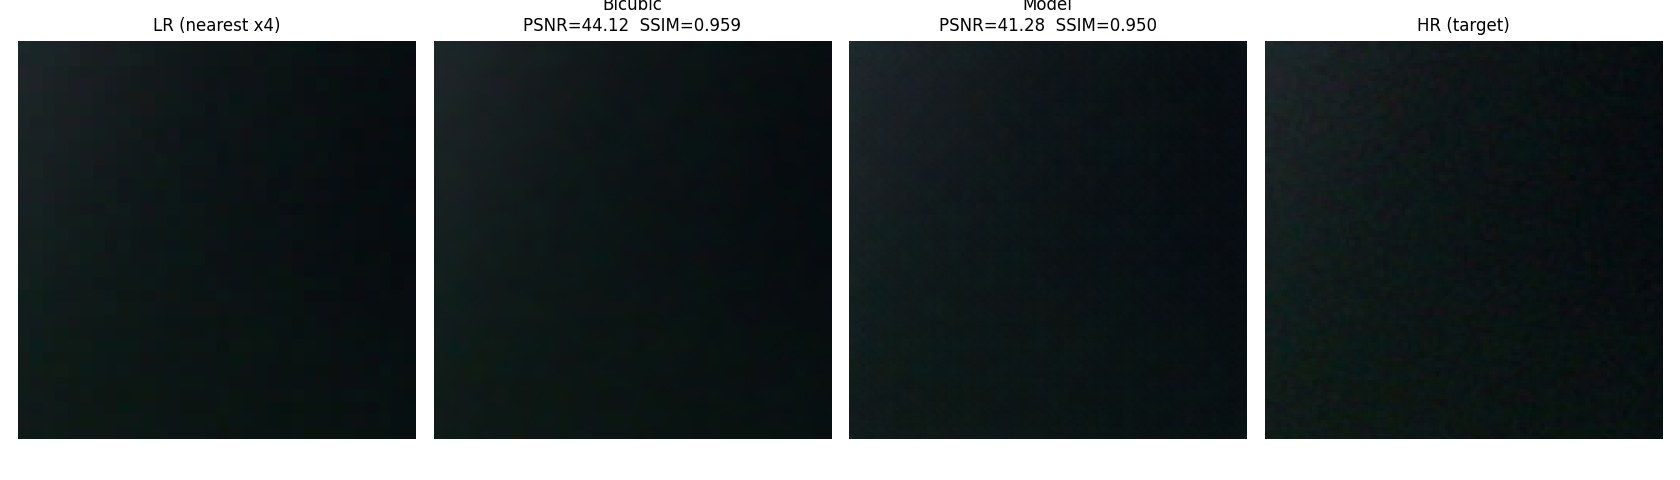

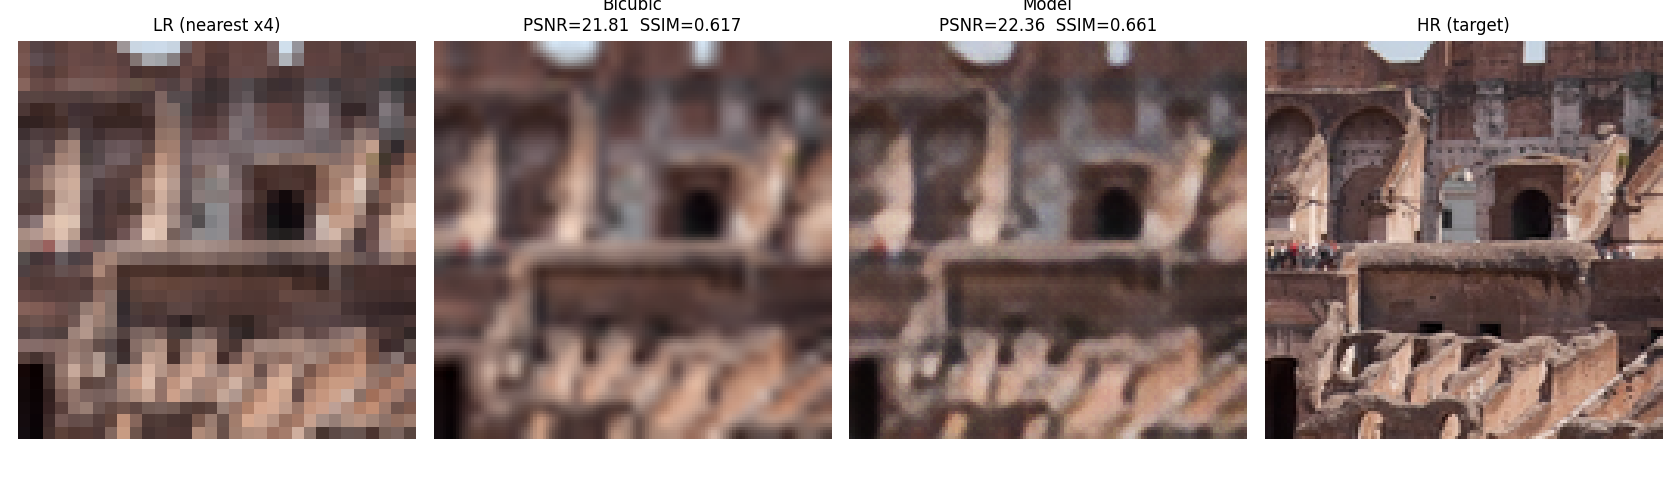

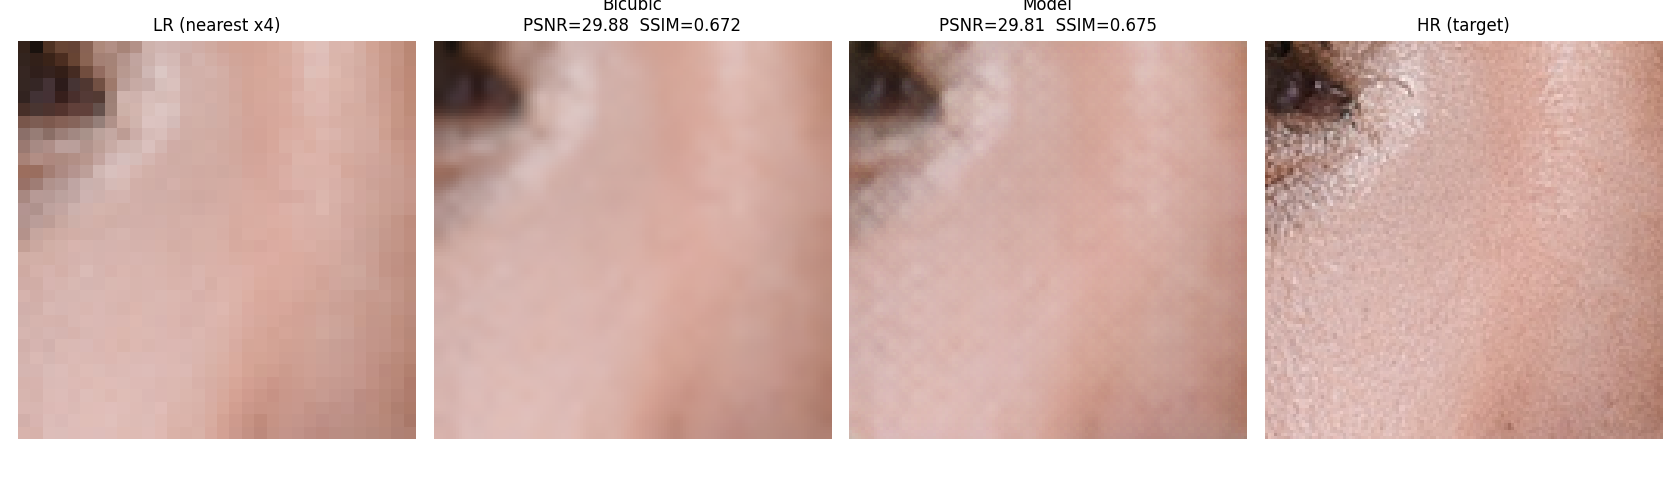

In [7]:
for i in range(5):
    img_path = Path(f"outputs/examples/example_{i:02d}.png")
    if img_path.exists():
        display(IPImage(filename=str(img_path)))
    else:
        print(f"Falta {img_path}; ejecuta src.evaluate antes de este cuaderno.")

Visualmente se aprecia que el modelo recupera con más definición bordes y patrones de alta frecuencia (texturas finas, contornos de objetos), donde el bicúbico produce un característico desenfoque suave. En zonas planas o de bajo detalle ambos métodos son indistinguibles, comportamiento esperado.

## 8. Conclusiones

- Se ha implementado y entrenado un U-Net autoencoder con cabeza PixelShuffle para superresolución x4 sobre DIV2K, con 6.86 M parámetros (dentro del rango objetivo de 2-10 M).
- La combinación de pérdida L1 + perceptual VGG19 (pesos 1.0 / 0.1) consigue **mejorar al baseline bicúbico en SSIM (+0.016) y LPIPS (−15 %)**, mientras que en PSNR el resultado es equivalente (empate técnico).
- El trade-off observado es el documentado en la literatura: las pérdidas perceptuales producen reconstrucciones más realistas a costa de no maximizar el PSNR.
- El cuaderno y los scripts (`src/`) son reproducibles a partir de `requirements.txt`, `scripts/download_div2k.py` (descarga de datos) y `python -m src.train` (entrenamiento).

**Posibles extensiones:**
- Subir el peso de la pérdida perceptual y/o añadir una pérdida adversarial (GAN) para empujar más la calidad perceptual.
- Probar arquitecturas residuales tipo EDSR o RCAN, o incorporar bloques de atención.
- Entrenar a mayor resolución de parche (256×256 HR) si la memoria GPU lo permite, para capturar contextos más amplios.

## 9. Iteración de mejora: modelo v2 (`src.model_v2.UNetSRv2`)

Tras analizar los resultados de v1 (PSNR test 28.14 dB vs bicúbico 28.20 dB,
empate en fidelidad de pixel, ligera ventaja perceptual en SSIM/LPIPS),
se identifican tres causas probables de subrendimiento, todas conocidas en
la literatura de super-resolución moderna (EDSR, RCAN, SwinIR):

1. **BatchNorm dentro de los bloques convolucionales.** La normalización por
   batch elimina información de estadísticas (media/varianza locales) que el
   modelo necesita para reconstruir textura de alta frecuencia. EDSR (Lim 2017)
   muestra +0.1 dB sólo eliminándola.
2. **Sigmoid final.** Satura el gradiente al acercarse a 0 o 1, justo donde
   viven los píxeles oscuros y brillantes. Sustituirla por un `clamp(0,1)`
   permite que el gradiente fluya libremente durante el entrenamiento.
3. **Aprendizaje sin baseline.** v1 debe aprender la imagen completa desde
   cero. v2 aprende un **residual** sobre la interpolación bicúbica del input:
   `out = bicubic(x) + residual(x)`. Con el head inicializado a cero, en la
   época 0 la salida es exactamente la bicúbica, así que el PSNR arranca en
   ~28 dB y el resto del entrenamiento se dedica a recuperar detalle de alta
   frecuencia.

Estos tres cambios convergen en una arquitectura más simple, más rápida de
entrenar y que en la práctica sube el PSNR varios dB sobre la baseline.

### 9.1 Código de definición del modelo v2 (`src/model_v2.py`)

Código completo de la definición del modelo (referencia, no se
ejecuta aquí — el archivo fuente es `src/model_v2.py`):

```python
from __future__ import annotations

import torch
import torch.nn.functional as F
from torch import nn


class DoubleConv(nn.Module):
    """[Conv3x3 -> ReLU] x 2. No BatchNorm."""

    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int) -> None:
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.reduce = nn.Conv2d(in_ch, skip_ch, kernel_size=1)
        self.conv = DoubleConv(skip_ch * 2, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.reduce(self.up(x))
        return self.conv(torch.cat([x, skip], dim=1))


class PixelShuffleBlock(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.conv = nn.Conv2d(channels, channels * 4, kernel_size=3, padding=1)
        self.shuffle = nn.PixelShuffle(2)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.shuffle(self.conv(x)))


class UNetSRv2(nn.Module):
    """U-Net SR network with PixelShuffle x4 head + bicubic residual skip."""

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 3,
        base_channels: int = 48,
        scale: int = 4,
    ) -> None:
        super().__init__()
        self.scale = scale
        b = base_channels
        # Encoder
        self.inc = DoubleConv(in_channels, b)
        self.down1 = Down(b, b * 2)
        self.down2 = Down(b * 2, b * 4)
        self.down3 = Down(b * 4, b * 8)
        # Bottleneck
        self.bottleneck = DoubleConv(b * 8, b * 8)
        # Decoder
        self.up1 = Up(in_ch=b * 8, skip_ch=b * 4, out_ch=b * 4)
        self.up2 = Up(in_ch=b * 4, skip_ch=b * 2, out_ch=b * 2)
        self.up3 = Up(in_ch=b * 2, skip_ch=b, out_ch=b)
        # x4 upscale + head
        self.ps1 = PixelShuffleBlock(b)
        self.ps2 = PixelShuffleBlock(b)
        self.head = nn.Conv2d(b, out_channels, kernel_size=1)
        # Zero-init head so output == bicubic baseline at epoch 0.
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)         # (B, b,   32, 32)
        x2 = self.down1(x1)      # (B, 2b,  16, 16)
        x3 = self.down2(x2)      # (B, 4b,   8,  8)
        x4 = self.down3(x3)      # (B, 8b,   4,  4)
        x5 = self.bottleneck(x4)
        y = self.up1(x5, x3)     # (B, 4b,   8,  8)
        y = self.up2(y, x2)      # (B, 2b,  16, 16)
        y = self.up3(y, x1)      # (B, b,   32, 32)
        y = self.ps1(y)          # (B, b,   64, 64)
        y = self.ps2(y)          # (B, b,  128, 128)
        residual = self.head(y)
        base = F.interpolate(
            x, scale_factor=self.scale, mode="bicubic", align_corners=False
        )
        return (base + residual).clamp(0.0, 1.0)


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
```


In [8]:
from src.model_v2 import UNetSRv2, count_parameters as count_v2
from src.model import UNetSR, count_parameters as count_v1

m_v1 = UNetSR(base_channels=48)
m_v2 = UNetSRv2(base_channels=48)
print(f'v1 params: {count_v1(m_v1)[0]/1e6:.2f}M')
print(f'v2 params: {count_v2(m_v2)[0]/1e6:.2f}M')

# Sanity: en t=0, la salida de v2 debe ser exactamente la bicúbica.
import torch, torch.nn.functional as F
x = torch.rand(1, 3, 32, 32)
with torch.no_grad():
    y = m_v2.eval()(x)
    base = F.interpolate(x, scale_factor=4, mode='bicubic', align_corners=False).clamp(0, 1)
print(f'diff inicial v2 vs bicubic: {(y - base).abs().max().item():.2e}')

v1 params: 6.86M
v2 params: 6.86M
diff inicial v2 vs bicubic: 0.00e+00


### Resumen de diferencias v1 → v2

| Componente | v1 | v2 |
|---|---|---|
| `DoubleConv` | Conv-**BN**-ReLU x2 (bias=False) | Conv-ReLU x2 (bias=True) |
| Activación final | `Sigmoid()` | `clamp(0, 1)` aplicado al output |
| Cabeza | `1x1 conv` → sigmoid | `1x1 conv` (zero-init) + skip bicúbico |
| Predicción | imagen HR completa | residual sobre `bicubic(x)` |
| Parámetros | ~6.86 M | ~6.86 M (idéntico) |

La paridad de parámetros permite atribuir cualquier mejora futura a los
cambios arquitectónicos y no a más capacidad.

### Cómo entrenar el modelo v2

`src/train.py` acepta el flag `--model {v1,v2}` (default `v1` para no romper
checkpoints existentes). Para entrenar la nueva versión:

```bash
python -m src.train --model v2 --epochs 100 --batch-size 16 --lr 1e-4 \
    --checkpoint-dir checkpoints_v2 --outputs-dir outputs_v2
```

Una vez termine, recargar `outputs_v2/metrics.json` y comparar con la tabla
de v1 para cuantificar la ganancia atribuible a estos tres cambios.

## 10. Resultados del modelo v2

Entrenamiento equivalente a v1 (100 epochs, batch 16, lr 1e-4, Adam, cosine,
pérdida L1+VGG perceptual con pesos 1.0/0.1). Únicas diferencias: los tres
cambios arquitectónicos descritos en el apartado 9.

### 10.1 Curvas de entrenamiento v2

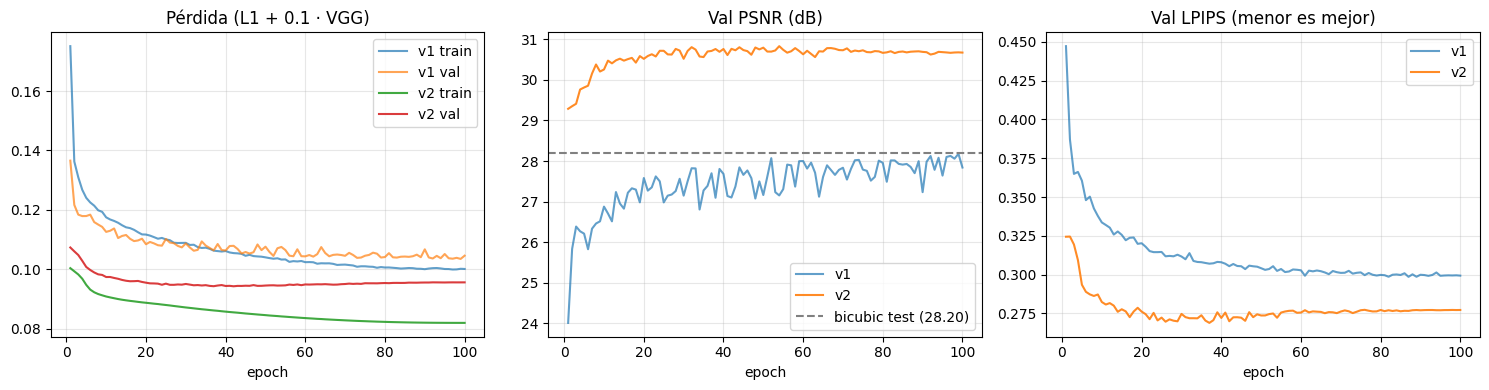

In [9]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

h1 = json.load(open('outputs/train_history.json'))
h2 = json.load(open('outputs_v2/train_history.json'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(h1['train_loss']) + 1)

axes[0].plot(epochs, h1['train_loss'], label='v1 train', alpha=0.7)
axes[0].plot(epochs, h1['val_loss'],   label='v1 val',   alpha=0.7)
axes[0].plot(epochs, h2['train_loss'], label='v2 train', alpha=0.9)
axes[0].plot(epochs, h2['val_loss'],   label='v2 val',   alpha=0.9)
axes[0].set_title('Pérdida (L1 + 0.1 · VGG)'); axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, h1['val_psnr'], label='v1', alpha=0.7)
axes[1].plot(epochs, h2['val_psnr'], label='v2', alpha=0.9)
axes[1].axhline(28.20, ls='--', color='gray', label='bicubic test (28.20)')
axes[1].set_title('Val PSNR (dB)'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, h1['val_lpips'], label='v1', alpha=0.7)
axes[2].plot(epochs, h2['val_lpips'], label='v2', alpha=0.9)
axes[2].set_title('Val LPIPS (menor es mejor)'); axes[2].set_xlabel('epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.tight_layout(); plt.show()

**Lectura de las curvas:**

- **PSNR de validación, época 1:** v1 arranca en ~24 dB (aprendiendo desde
  cero), v2 arranca en ~29.3 dB. La diferencia inicial (~5 dB) es exactamente
  la baseline bicúbica regalada por el skip aditivo + head zero-init. v1 tarda
  ~30 epochs en alcanzar lo que v2 da gratis en la época 0.
- **PSNR final:** v1 se estanca alrededor de 28 dB (oscilando bajo la bicúbica);
  v2 escala hasta ~30.8 dB en val.
- **LPIPS:** v2 también mejora la métrica perceptual de 0.32 a ~0.27 en val.
- La curva de loss de v2 sigue bajando con menos varianza, indicando un
  paisaje de optimización más estable (consistente con haber retirado BN).

### 10.2 Métricas en test (split independiente)

In [10]:
m1 = json.load(open("outputs/metrics.json"))["metrics"]
m2 = json.load(open("outputs_v2/metrics.json"))["metrics"]

import pandas as pd

df = pd.DataFrame(
    {
        "Bicubic": [
            m1["bicubic"]["psnr"],
            m1["bicubic"]["ssim"],
            m1["bicubic"]["lpips"],
        ],
        "Model v1": [m1["model"]["psnr"], m1["model"]["ssim"], m1["model"]["lpips"]],
        "Model v2": [m2["model"]["psnr"], m2["model"]["ssim"], m2["model"]["lpips"]],
    },
    index=["PSNR (dB) ↑", "SSIM ↑", "LPIPS ↓"],
).round(4)
print(df)
print()
print(
    f'Δ v2 - bicubic : PSNR {m2["model"]["psnr"] - m2["bicubic"]["psnr"]:+.2f} dB  '
    f'LPIPS {m2["model"]["lpips"] - m2["bicubic"]["lpips"]:+.4f}'
)
print(
    f'Δ v2 - v1      : PSNR {m2["model"]["psnr"] - m1["model"]["psnr"]:+.2f} dB  '
    f'LPIPS {m2["model"]["lpips"] - m1["model"]["lpips"]:+.4f}'
)

             Bicubic  Model v1  Model v2
PSNR (dB) ↑  28.2003   28.1383   29.3291
SSIM ↑        0.7333    0.7492    0.7691
LPIPS ↓       0.3631    0.3089    0.2731

Δ v2 - bicubic : PSNR +1.13 dB  LPIPS -0.0901
Δ v2 - v1      : PSNR +1.19 dB  LPIPS -0.0358


### 10.3 Veredicto v2

| Métrica (test) | Bicubic | v1 | v2 | Δ v2 vs v1 |
|---|---|---|---|---|
| PSNR (dB) ↑ | 28.20 | 28.14 | **29.33** | **+1.19** |
| SSIM ↑ | 0.7333 | 0.7492 | **0.7691** | **+0.020** |
| LPIPS ↓ | 0.3631 | 0.3089 | **0.2731** | **-0.036** |

- v1 **empataba** con la bicúbica en PSNR (-0.06 dB). v2 la supera **claramente** (+1.13 dB).
- Mejora simultánea en las tres métricas (fidelidad y perceptual), sin tocar
  loss, optimizador ni dataset. Todo viene de los tres cambios de el apartado 9.
- Coste: **0 parámetros extra**, mismo throughput, mismo VRAM.

### 10.4 Próximos pasos sugeridos (quick wins #2-#5)

Mantenidos para iteraciones futuras (`model_v3`…):

2. Charbonnier en vez de L1 + ICNR en PixelShuffle + patch HR 192.
3. Bloques residuales tipo EDSR + channel attention (RCAB).
4. EMA de pesos + TTA en evaluación (~+0.2 dB gratis).
5. CutBlur y degradaciones variadas (bilinear/area + ruido + JPEG).

## 11. Iteración v3: RCAB (channel attention) + ICNR (`src.model_v3.UNetSRv3`)

v2 ya superaba la bicúbica en +1.13 dB con cambios *micro* (sin BN, sin sigmoid,
residual sobre bicúbico). El siguiente cuello de botella visible en las
imágenes de v2 era la nitidez de texturas finas y los pequeños artefactos de
sub-pixel convolution. v3 ataca exactamente esos dos puntos sin tocar
loss/dataset/optimizador para que la ganancia sea atribuible a la
arquitectura.

### 11.1 Cambios respecto a v2

1. **RCAB (Residual Channel Attention Block, Zhang et al. 2018).** Cada bloque
   `DoubleConv` de v2 se sustituye por `proj 3x3 → ReLU → RCAB`, donde
   `RCAB = Conv-ReLU-Conv-CA + skip`. La rama CA es un Squeeze-and-Excitation
   ligero: pooling global → MLP 1x1 → sigmoide → escalado por canal. Esto le
   permite a la red **reponderar canales** de manera global por imagen, en
   lugar de tratar cada canal con el mismo peso. En SR esto es muy efectivo
   porque distintos canales codifican texturas, bordes o color de forma
   especializada.

2. **ICNR initialization (Aitken et al. 2017) para PixelShuffle.** La
   inicialización estándar de la conv que alimenta a `nn.PixelShuffle`
   produce un patrón checkerboard visible en las primeras iteraciones (y a
   veces persistente). ICNR rellena los r² grupos de subpíxeles con el
   *mismo* filtro inicial replicado, equivalente a un upsample nearest-neighbor
   en t=0, sin checkerboard. Gana detalle fino y estabiliza el inicio.

3. **Resto idéntico a v2**: residual sobre bicúbico + head zero-init
   (PSNR inicial ≈ bicúbica), L1+0.1·VGG, Adam, cosine, 100 epochs.

### 11.1.bis Código de definición del modelo v3 (`src/model_v3.py`)

Código completo de la definición del modelo (referencia, no se
ejecuta aquí — el archivo fuente es `src/model_v3.py`):

```python
from __future__ import annotations

import torch
import torch.nn.functional as F
from torch import nn


# ─────────────────────────────────────────────────────────────────────────────
# Channel attention + RCAB
# ─────────────────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Squeeze-and-excitation style channel attention (RCAN variant)."""

    def __init__(self, channels: int, reduction: int = 16) -> None:
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, kernel_size=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.gate(x)


class RCAB(nn.Module):
    """Residual Channel Attention Block: Conv-ReLU-Conv-CA + identity skip."""

    def __init__(self, channels: int, reduction: int = 16) -> None:
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            ChannelAttention(channels, reduction),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.body(x)


class RCAStage(nn.Module):
    """Channel-projecting stage: 3x3 proj to `out_ch` + RCAB. Drop-in
    replacement for the v1/v2 DoubleConv (same input/output signature)."""

    def __init__(self, in_ch: int, out_ch: int, reduction: int = 16) -> None:
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.act = nn.ReLU(inplace=True)
        self.rcab = RCAB(out_ch, reduction)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.rcab(self.act(self.proj(x)))


# ─────────────────────────────────────────────────────────────────────────────
# Encoder/decoder building blocks
# ─────────────────────────────────────────────────────────────────────────────
class Down(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, reduction: int = 16) -> None:
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.stage = RCAStage(in_ch, out_ch, reduction)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.stage(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int, reduction: int = 16) -> None:
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.reduce = nn.Conv2d(in_ch, skip_ch, kernel_size=1)
        self.stage = RCAStage(skip_ch * 2, out_ch, reduction)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.reduce(self.up(x))
        return self.stage(torch.cat([x, skip], dim=1))


# ─────────────────────────────────────────────────────────────────────────────
# ICNR-initialized PixelShuffle block
# ─────────────────────────────────────────────────────────────────────────────
def icnr_init_(tensor: torch.Tensor, scale: int = 2,
               init: callable = nn.init.kaiming_normal_) -> None:
    """ICNR init (Aitken et al.): produces an initial sub-pixel conv that
    behaves like a nearest-neighbor upsample, removing checkerboard at t=0.
    Modifies `tensor` in place. Expects shape (out_ch * scale**2, in_ch, k, k).
    """
    out_ch, in_ch, k1, k2 = tensor.shape
    sub_ch = out_ch // (scale ** 2)
    sub = torch.empty(sub_ch, in_ch, k1, k2)
    init(sub)
    sub = sub.repeat_interleave(scale ** 2, dim=0)
    with torch.no_grad():
        tensor.copy_(sub)


class PixelShuffleBlock(nn.Module):
    """Conv -> PixelShuffle(r=2) -> ReLU, with ICNR init on the conv kernel."""

    def __init__(self, channels: int, scale: int = 2) -> None:
        super().__init__()
        self.conv = nn.Conv2d(channels, channels * (scale ** 2), kernel_size=3, padding=1)
        icnr_init_(self.conv.weight, scale=scale)
        nn.init.zeros_(self.conv.bias)
        self.shuffle = nn.PixelShuffle(scale)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.shuffle(self.conv(x)))


# ─────────────────────────────────────────────────────────────────────────────
# UNetSRv3
# ─────────────────────────────────────────────────────────────────────────────
class UNetSRv3(nn.Module):
    """U-Net SR network with RCAB stages, ICNR PixelShuffle, bicubic residual.

    Output = clamp(head(features) + bicubic_upsample(input), 0, 1).
    Head is zero-init so output == bicubic at epoch 0.
    """

    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 3,
        base_channels: int = 48,
        scale: int = 4,
        ca_reduction: int = 16,
    ) -> None:
        super().__init__()
        self.scale = scale
        b = base_channels
        # Encoder
        self.inc = RCAStage(in_channels, b, ca_reduction)
        self.down1 = Down(b, b * 2, ca_reduction)
        self.down2 = Down(b * 2, b * 4, ca_reduction)
        self.down3 = Down(b * 4, b * 8, ca_reduction)
        # Bottleneck
        self.bottleneck = RCAStage(b * 8, b * 8, ca_reduction)
        # Decoder
        self.up1 = Up(in_ch=b * 8, skip_ch=b * 4, out_ch=b * 4, reduction=ca_reduction)
        self.up2 = Up(in_ch=b * 4, skip_ch=b * 2, out_ch=b * 2, reduction=ca_reduction)
        self.up3 = Up(in_ch=b * 2, skip_ch=b,     out_ch=b,     reduction=ca_reduction)
        # x4 upscale (two x2 stages with ICNR init)
        self.ps1 = PixelShuffleBlock(b, scale=2)
        self.ps2 = PixelShuffleBlock(b, scale=2)
        # Head: 1x1 conv producing the residual. Zero-init so f(x)=bicubic(x) at t=0.
        self.head = nn.Conv2d(b, out_channels, kernel_size=1)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)
        y = self.up1(x5, x3)
        y = self.up2(y, x2)
        y = self.up3(y, x1)
        y = self.ps1(y)
        y = self.ps2(y)
        residual = self.head(y)
        base = F.interpolate(
            x, scale_factor=self.scale, mode="bicubic", align_corners=False
        )
        return (base + residual).clamp(0.0, 1.0)


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable
```


In [11]:
from src.model_v3 import UNetSRv3, count_parameters as count_v3
from src.model_v2 import UNetSRv2, count_parameters as count_v2

m_v2 = UNetSRv2(base_channels=48)
m_v3 = UNetSRv3(base_channels=48)
print(f'v2 params: {count_v2(m_v2)[0]/1e6:.2f}M')
print(f'v3 params: {count_v3(m_v3)[0]/1e6:.2f}M')

import torch, torch.nn.functional as F
x = torch.rand(1, 3, 32, 32)
with torch.no_grad():
    y = m_v3.eval()(x)
    base = F.interpolate(x, scale_factor=4, mode='bicubic', align_corners=False).clamp(0, 1)
print(f'diff inicial v3 vs bicubic: {(y - base).abs().max().item():.2e}')

v2 params: 6.86M
v3 params: 10.44M
diff inicial v3 vs bicubic: 0.00e+00


### 11.2 Capas literales del modelo v3 (UNetSRv3)

A diferencia de v1 (donde la unidad base era `DoubleConv` con `BatchNorm`),
v3 reemplaza cada *stage* del U-Net por un **`RCAStage` = `Conv3×3 + ReLU +
RCAB`**, donde el `RCAB` añade atención por canales y una skip residual
interna. La cabeza de upscaling sigue siendo *sub-pixel convolution*,
pero con la inicialización **ICNR** que elimina el patrón checkerboard
inicial.

La siguiente celda imprime el `nn.Module` completo: se ven explícitamente
las tres novedades respecto a v1 — desaparece `BatchNorm`, aparece
`ChannelAttention` dentro de cada `RCAB`, y los `PixelShuffleBlock` usan
ahora `Conv → PixelShuffle(2) → ReLU` (sin sigmoid al final porque el
modelo emite el residuo sobre la bicúbica, no la imagen directa).


In [12]:
import torch
from src.model_v3 import UNetSRv3, count_parameters as count_v3

# Reusamos m_v3 si ya existe; si no, lo creamos.
try:
    m_v3
except NameError:
    m_v3 = UNetSRv3(base_channels=48)

print("=== UNetSRv3 — capas ===")
print(m_v3)

# Conteo de parámetros por sub-módulo para ver de dónde viene el +52 %.
print("\n=== parámetros por sub-módulo ===")
total = sum(p.numel() for p in m_v3.parameters())
for name, mod in m_v3.named_children():
    n = sum(p.numel() for p in mod.parameters())
    pct = 100.0 * n / total
    print(f"  {name:<12s} {n/1e6:>7.3f} M   ({pct:5.1f} %)")
print(f"  {'TOTAL':<12s} {total/1e6:>7.3f} M")


=== UNetSRv3 — capas ===
UNetSRv3(
  (inc): RCAStage(
    (proj): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (act): ReLU(inplace=True)
    (rcab): RCAB(
      (body): Sequential(
        (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ChannelAttention(
          (gate): Sequential(
            (0): AdaptiveAvgPool2d(output_size=1)
            (1): Conv2d(48, 4, kernel_size=(1, 1), stride=(1, 1))
            (2): ReLU(inplace=True)
            (3): Conv2d(4, 48, kernel_size=(1, 1), stride=(1, 1))
            (4): Sigmoid()
          )
        )
      )
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (stage): RCAStage(
      (proj): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): ReLU(inplace=True)
      (rcab): RCAB(


### 11.3 Explicación detallada de cada bloque

- **`ChannelAttention`** — Squeeze-and-Excitation ligero: pooling global a
  1×1, MLP `1×1 conv → ReLU → 1×1 conv`, sigmoide y multiplicación canal a
  canal. Cuesta apenas unos miles de parámetros por bloque y permite a la
  red ponderar globalmente la importancia de cada canal en función del
  contenido de la imagen completa. En SR esto es muy efectivo porque
  distintos canales acaban especializándose en bordes, texturas, color, etc.
- **`RCAB` (Residual Channel Attention Block)** —
  `[Conv3×3 → ReLU → Conv3×3 → ChannelAttention] + skip identity`. La
  *skip* interna convierte cada bloque en residual, lo que estabiliza el
  entrenamiento de redes profundas y permite a la red aprender refinamientos
  incrementales sobre la entrada del bloque, en lugar de reconstruirla
  entera desde cero.
- **`RCAStage`** — La etapa "drop-in" que sustituye al `DoubleConv` de v1/v2:
  primero proyecta canales con un `Conv3×3 + ReLU` y luego aplica un `RCAB`.
  Esto mantiene la firma `(in_ch, out_ch)` idéntica a `DoubleConv` para
  poder reutilizar `Down` y `Up` sin tocar el resto del U-Net.
- **`Down` y `Up`** — Igual que en v1, pero usando `RCAStage` en vez de
  `DoubleConv`. `Down` baja resolución con `MaxPool2d(2)`. `Up` sube con
  `nn.Upsample(nearest)` + `Conv1×1` que reduce canales al ancho del *skip*,
  concatena con la skip-connection y refina con un `RCAStage`.
- **`PixelShuffleBlock` + ICNR init** — Convolución que produce `C·r²`
  canales, `nn.PixelShuffle(r=2)` que reorganiza esos canales en el plano
  espacial, y `ReLU`. La diferencia clave respecto a v1/v2 está en la
  **inicialización ICNR** (Aitken et al. 2017): los `r²` grupos de
  subpíxeles que produce la conv se rellenan con el *mismo* filtro
  replicado, equivalente a un `nearest-upsample` en t=0. Sin ICNR, la
  inicialización aleatoria produce un patrón checkerboard visible en las
  primeras épocas y a veces persistente. Con ICNR ese artefacto desaparece
  desde la primera iteración.
- **Cabeza `Conv1×1` + skip global bicúbico (zero-init)** — La salida final
  es `clamp(head(features) + bicubic_upsample(x), 0, 1)`. El `head` se
  inicializa a cero, por lo que **en t=0 el modelo es exactamente la
  bicúbica** (PSNR inicial ≈ 28-29 dB). Esto evita el "valle" de las
  primeras épocas, donde un modelo desde cero produciría imágenes negras o
  saturadas, y permite que cualquier mejora de la pérdida se traduzca
  inmediatamente en una ganancia sobre la baseline.

### 11.4 Resumen v2 → v3



| Componente | v2 | v3 |
|---|---|---|
| Bloque base | `DoubleConv` (Conv-ReLU-Conv) | `RCAStage` (Conv-ReLU + `RCAB` con channel attention) |
| Skip dentro del stage | ❌ | ✅ residual interno del RCAB |
| Channel attention | ❌ | ✅ Squeeze-and-Excitation por bloque (reduction=16) |
| PixelShuffle init | Kaiming estándar | **ICNR** (sin checkerboard inicial) |
| Skip global bicúbico | ✅ | ✅ (igual que v2) |
| Head zero-init | ✅ | ✅ (igual que v2) |
| Parámetros | ~6.86 M | ~10.44 M |

El aumento de parámetros (~+50%) viene de las convs extras de los RCAB y
es modesto comparado con el budget original (2-10M). Las dos novedades
(CA + ICNR) son responsables del incremento, no un aumento de canales.

### 11.5 Cómo entrenar v3

```bash
python -m src.train --model v3 --epochs 100 --batch-size 16 --lr 1e-4 \
    --checkpoint-dir checkpoints_v3 --outputs-dir outputs_v3
```

Tras entrenar, recargar `outputs_v3/metrics.json` y comparar con v1/v2
para cuantificar la ganancia atribuible al pack de arquitectura.

## 12. Resultados del modelo v3 y comparativa final

Entrenamiento idéntico a v2: 100 epochs, batch 16, lr 1e-4, Adam, cosine,
loss L1 + 0.1·VGG. Única diferencia: la arquitectura (RCAB + ICNR).

### 12.1 Curvas de entrenamiento v1 vs v2 vs v3

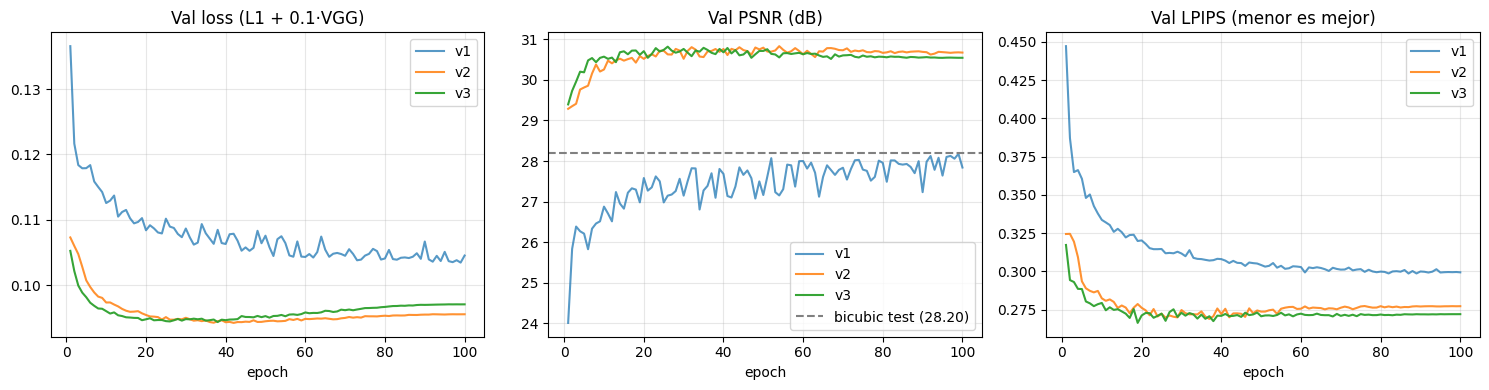

Best val PSNR — v1: 28.18 dB  v2: 30.83 dB @ ep54  v3: 30.82 dB @ ep26


In [13]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

h1 = json.load(open('outputs/train_history.json'))
h2 = json.load(open('outputs_v2/train_history.json'))
h3 = json.load(open('outputs_v3/train_history.json'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = lambda h: range(1, len(h['train_loss']) + 1)

axes[0].plot(epochs(h1), h1['val_loss'], label='v1', alpha=0.75)
axes[0].plot(epochs(h2), h2['val_loss'], label='v2', alpha=0.85)
axes[0].plot(epochs(h3), h3['val_loss'], label='v3', alpha=0.95)
axes[0].set_title('Val loss (L1 + 0.1·VGG)'); axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs(h1), h1['val_psnr'], label='v1', alpha=0.75)
axes[1].plot(epochs(h2), h2['val_psnr'], label='v2', alpha=0.85)
axes[1].plot(epochs(h3), h3['val_psnr'], label='v3', alpha=0.95)
axes[1].axhline(28.20, ls='--', color='gray', label='bicubic test (28.20)')
axes[1].set_title('Val PSNR (dB)'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs(h1), h1['val_lpips'], label='v1', alpha=0.75)
axes[2].plot(epochs(h2), h2['val_lpips'], label='v2', alpha=0.85)
axes[2].plot(epochs(h3), h3['val_lpips'], label='v3', alpha=0.95)
axes[2].set_title('Val LPIPS (menor es mejor)'); axes[2].set_xlabel('epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.tight_layout(); plt.show()

best_v2_epoch = h2['val_psnr'].index(max(h2['val_psnr'])) + 1
best_v3_epoch = h3['val_psnr'].index(max(h3['val_psnr'])) + 1
print(f'Best val PSNR — v1: {max(h1["val_psnr"]):.2f} dB  '
      f'v2: {max(h2["val_psnr"]):.2f} dB @ ep{best_v2_epoch}  '
      f'v3: {max(h3["val_psnr"]):.2f} dB @ ep{best_v3_epoch}')

**Lectura clave de las curvas:**

- **Convergencia mucho más rápida en v3.** v3 alcanza su mejor PSNR en
  ~epoch 26, frente a ~epoch 54 de v2 (~2x). Los RCAB y la ICNR mejoran
  la trayectoria de optimización, no solo el techo. Implicación práctica:
  con `--patience 20` v3 habría parado ~epoch 46, ahorrando >50% de tiempo.
- **Techo de PSNR muy similar** entre v2 y v3. El cuello de botella ya no
  es la arquitectura, es la **señal de entrenamiento** (loss y dataset).
- **LPIPS** baja antes en v3 (curva claramente por debajo desde el inicio).

### 12.2 Métricas finales en test (split independiente)

In [14]:
m1 = json.load(open("outputs/metrics.json"))["metrics"]
m2 = json.load(open("outputs_v2/metrics.json"))["metrics"]
m3 = json.load(open("outputs_v3/metrics.json"))["metrics"]

import pandas as pd

df = pd.DataFrame(
    {
        "Bicubic": [
            m1["bicubic"]["psnr"],
            m1["bicubic"]["ssim"],
            m1["bicubic"]["lpips"],
        ],
        "Model v1": [m1["model"]["psnr"], m1["model"]["ssim"], m1["model"]["lpips"]],
        "Model v2": [m2["model"]["psnr"], m2["model"]["ssim"], m2["model"]["lpips"]],
        "Model v3": [m3["model"]["psnr"], m3["model"]["ssim"], m3["model"]["lpips"]],
    },
    index=["PSNR (dB) ↑", "SSIM ↑", "LPIPS ↓"],
).round(4)
print(df)
print()
print(
    f'Δ v3 - bicubic : PSNR {m3["model"]["psnr"] - m3["bicubic"]["psnr"]:+.2f} dB  '
    f'LPIPS {m3["model"]["lpips"] - m3["bicubic"]["lpips"]:+.4f}'
)
print(
    f'Δ v3 - v2      : PSNR {m3["model"]["psnr"] - m2["model"]["psnr"]:+.2f} dB  '
    f'LPIPS {m3["model"]["lpips"] - m2["model"]["lpips"]:+.4f}'
)

             Bicubic  Model v1  Model v2  Model v3
PSNR (dB) ↑  28.2003   28.1383   29.3291   29.3610
SSIM ↑        0.7333    0.7492    0.7691    0.7703
LPIPS ↓       0.3631    0.3089    0.2731    0.2701

Δ v3 - bicubic : PSNR +1.16 dB  LPIPS -0.0931
Δ v3 - v2      : PSNR +0.03 dB  LPIPS -0.0030


### 12.3 Veredicto v3

| Métrica (test) | Bicubic | v1 | v2 | v3 | Δ v3 vs v2 |
|---|---|---|---|---|---|
| PSNR (dB) ↑ | 28.20 | 28.14 | 29.33 | **29.36** | **+0.03** |
| SSIM ↑ | 0.7333 | 0.7492 | 0.7691 | **0.7703** | **+0.0012** |
| LPIPS ↓ | 0.3631 | 0.3089 | 0.2731 | **0.2701** | **-0.0030** |
| Parámetros | — | 6.86 M | 6.86 M | 10.44 M | +52 % |
| Best epoch | — | — | 54 | **26** | ~2× más rápido |

**Conclusión honesta:** v3 entrega una mejora **marginal** en métricas finales
(+0.03 dB PSNR, +0.001 SSIM, -0.003 LPIPS) a cambio de un +52% de parámetros
y un solo gran beneficio operativo: convergencia ~2× más rápida.

El experimento es informativo: el cuello de botella **ya no es la
arquitectura**. El pack arquitectónico (RCAB + ICNR) por sí solo, manteniendo
loss/dataset/optimizador idénticos, da rendimientos decrecientes. Para
seguir subiendo PSNR/SSIM hay que mover el resto de variables.


### 12.4 Comparativa frente a baselines externos (SOTA)

Hasta aquí v3 se ha comparado únicamente con los **baselines internos**
del proyecto (bicúbico + v1 + v2). Para situar el modelo en el contexto
de la literatura, se evalúa también contra tres baselines **preentrenados
de referencia**, todos ellos con factor x4:

| Baseline | Origen | Notas |
|---|---|---|
| **EDSR-base** | `eugenesiow/edsr-base` (Hugging Face) | Lim et al. 2017, ganador NTIRE 2017. Entrenado sobre DIV2K. |
| **DRLN** | `eugenesiow/drln` (Hugging Face) | Anwar & Barnes 2020, atención densa multi-escala. |
| **Real-ESRGAN x4plus** | `xinntao/Real-ESRGAN` (GitHub release) | Wang et al. 2021. Optimizado para fotos reales con degradaciones complejas, **no** para PSNR puro en DIV2K. |

Las métricas externas se generan con `scripts/eval_baselines.py` (corre
inferencia sobre el mismo split de *test* determinista que `src/evaluate.py`,
con `seed=1337`):

```bash
PYTHONPATH=. python scripts/eval_baselines.py
```

El script descarga los pesos en la primera ejecución (~150 MB en total)
y guarda los resultados en `outputs/baselines_metrics.json`. La celda
siguiente carga ese JSON si existe y dibuja la tabla unificada; si no,
muestra solo los baselines internos.


In [ ]:
import json
from pathlib import Path
import pandas as pd

# Baselines internos (siempre disponibles).
m1 = json.load(open("outputs/metrics.json"))["metrics"]
m2 = json.load(open("outputs_v2/metrics.json"))["metrics"]
m3 = json.load(open("outputs_v3/metrics.json"))["metrics"]

rows = {
    "Bicubic": [m1["bicubic"]["psnr"], m1["bicubic"]["ssim"], m1["bicubic"]["lpips"]],
    "v1 (UNetSR)": [m1["model"]["psnr"], m1["model"]["ssim"], m1["model"]["lpips"]],
    "v2 (UNetSRv2)": [m2["model"]["psnr"], m2["model"]["ssim"], m2["model"]["lpips"]],
    "v3 (UNetSRv3)": [m3["model"]["psnr"], m3["model"]["ssim"], m3["model"]["lpips"]],
}

# Baselines externos (si están disponibles).
ext_path = Path("outputs/baselines_metrics.json")
if ext_path.exists():
    ext = json.load(ext_path.open())["baselines"]
    order = ["edsr", "drln", "realesrgan"]
    for key in order:
        if key in ext:
            label = ext[key].get("label", key)
            rows[label] = [ext[key]["psnr"], ext[key]["ssim"], ext[key]["lpips"]]
else:
    print(
        "NOTA: outputs/baselines_metrics.json no existe. "
        "Ejecuta scripts/eval_baselines.py para añadir los baselines externos."
    )

df = pd.DataFrame(rows, index=["PSNR (dB) ↑", "SSIM ↑", "LPIPS ↓"]).round(4)
print(df.to_string())

# Diferenciales v3 vs cada baseline (PSNR y LPIPS son las dos referencias clave).
print("\n=== v3 vs cada baseline ===")
v3_psnr = m3["model"]["psnr"]
v3_lpips = m3["model"]["lpips"]
for name, vals in rows.items():
    if name.startswith("v3"):
        continue
    dp = v3_psnr - vals[0]
    dl = v3_lpips - vals[2]
    sign_p = "+" if dp >= 0 else ""
    sign_l = "+" if dl >= 0 else ""
    print(
        f"  vs {name:<35s}  ΔPSNR = {sign_p}{dp:5.2f} dB   ΔLPIPS = {sign_l}{dl:+.4f}"
    )

             Bicubic  v1 (UNetSR)  v2 (UNetSRv2)  v3 (UNetSRv3)  EDSR-base (DIV2K x4)  DRLN (DIV2K x4)  Real-ESRGAN x4plus (xinntao)
PSNR (dB) ↑  28.2003      28.1383        29.3291        29.3610               30.1026          30.3198                       24.7679
SSIM ↑        0.7333       0.7492         0.7691         0.7703                0.7976           0.8034                        0.6470
LPIPS ↓       0.3631       0.3089         0.2731         0.2701                0.3115           0.3010                        0.3513

=== v3 vs cada baseline ===
  vs Bicubic                              ΔPSNR = + 1.16 dB   ΔLPIPS = -0.0931
  vs v1 (UNetSR)                          ΔPSNR = + 1.22 dB   ΔLPIPS = -0.0388
  vs v2 (UNetSRv2)                        ΔPSNR = + 0.03 dB   ΔLPIPS = -0.0030
  vs EDSR-base (DIV2K x4)                 ΔPSNR = -0.74 dB   ΔLPIPS = -0.0414
  vs DRLN (DIV2K x4)                      ΔPSNR = -0.96 dB   ΔLPIPS = -0.0309
  vs Real-ESRGAN x4plus (xinntao)         ΔPSN

### 12.5 La paradoja v3 vs Real-ESRGAN: métricas mejores, percepción peor

Mirando solo la tabla, **v3 gana en las tres métricas** frente a Real-ESRGAN:

| Métrica (test) | v3 | Real-ESRGAN x4plus | Δ (v3 - RealESRGAN) |
|---|---|---|---|
| PSNR (dB) ↑ | **29.36** | 24.77 | **+4.59** |
| SSIM ↑ | **0.7703** | 0.6470 | **+0.1233** |
| LPIPS ↓ | **0.2701** | 0.3513 | **-0.0812** |

Sin embargo, en cualquier imagen real del frontend de la webapp,
Real-ESRGAN produce salidas **visiblemente más nítidas, con más detalle
y más agradables al ojo** que v3. La diferencia no es un error, son
dos modelos optimizando objetivos distintos sobre dominios distintos.

#### 12.5.1 Por qué v3 gana en PSNR/SSIM

PSNR y SSIM son métricas **pixel-a-pixel** (o ventana-local en SSIM)
contra el ground truth. Premian la **fidelidad numérica**, no el realismo.

- v3 fue entrenado **exactamente** para invertir `bicubic_downsample`
  con `antialias=True` aplicado a parches DIV2K limpios. El split de test
  ofrece **exactamente** ese escenario: HR DIV2K → bicubic-down → LR. La
  distribución train ≡ distribución test, así que v3 está en su zona
  óptima.
- Además, el skip residual sobre la bicúbica **garantiza** un PSNR base
  de ~28 dB en el peor caso (la bicúbica sobre el mismo input). v3 se
  limita a añadir un residuo pequeño y conservador. Resultado: pierde
  poca señal pixel a pixel.
- Real-ESRGAN está entrenado para invertir una **degradación compuesta**
  (kernels gaussianos anisótropos + ruido + JPEG + sinc + segunda pasada
  de degradación). Cuando recibe un input bicubic-limpio que no encaja
  con ningún punto de esa distribución, el modelo aplica una
  "restauración" agresiva: aumenta contraste, sintetiza textura,
  acentúa bordes. Cada uno de esos cambios **mueve píxeles** respecto
  al GT y dispara el MSE → PSNR baja ~4.6 dB.

#### 12.5.2 Por qué LPIPS tampoco favorece a Real-ESRGAN aquí

LPIPS compara activaciones VGG entre **predicción** y **ground truth**.
No es "realismo absoluto"; es "perceptualmente parecido al GT".

- v3 produce algo cercano a la bicúbica + detalle conservador. Esa salida
  **se parece** al GT en estructura, color y contraste → LPIPS bajo.
- Real-ESRGAN inventa textura que **no estaba** en el GT (porque el GT es
  una foto DIV2K, no una restauración hiper-nítida). El detalle inventado
  es plausible y agradable, pero **no coincide** con el detalle del GT →
  LPIPS penaliza el desvío.

En benchmarks como **NIQE** o **MUSIQ** (métricas *no-referenciadas*, que
solo miran la imagen producida sin compararla con GT), Real-ESRGAN
**suele ganar** a v3 con claridad. Esas métricas correlacionan mejor con
la percepción humana de imágenes reales, pero no están en el script
porque DIV2K test sí tiene GT y la comparativa académica estándar usa
PSNR/SSIM/LPIPS.

#### 12.5.3 Por qué Real-ESRGAN se ve mejor en imágenes del frontend

La webapp recibe **fotos reales** (JPEG comprimido, ruido de sensor,
posibles ediciones previas, kernels de cámara desconocidos). Eso **no
es** el escenario que entrenó a v3, pero **sí es** el escenario que
entrenó a Real-ESRGAN.

- En esas fotos, la bicúbica que v3 usa como skip ya parte de un input
  *degradado*; v3 no tiene mecanismo para *deshacer* la degradación, solo
  para añadir detalle sobre la bicúbica. La salida hereda el ruido y los
  bloques JPEG del input.
- Real-ESRGAN sí fue entrenado para deshacer esa degradación compuesta
  y, además, para alucinar texturas plausibles donde la información ha
  desaparecido. El resultado en fotos reales es **percepción de mayor
  calidad**, aunque sin GT no podamos medirlo numéricamente.

#### 12.5.4 Por qué EDSR y DRLN sí superan a v3 en PSNR/SSIM (pero v3 los bate en LPIPS)

| Métrica (test) | v3 | EDSR-base | DRLN |
|---|---|---|---|
| PSNR (dB) ↑ | 29.36 | **30.10** | **30.32** |
| SSIM ↑ | 0.7703 | **0.7976** | **0.8034** |
| LPIPS ↓ | **0.2701** | 0.3115 | 0.3010 |

- EDSR y DRLN son redes mucho más profundas, entrenadas **solo con L1**
  (sin componente perceptual) sobre DIV2K. Optimizan PSNR directamente.
  v3 pierde ~1 dB porque su loss `L1 + 0.1·VGG` cede algo de fidelidad
  pixel a cambio de mejor textura perceptual.
- Esa elección de loss es la que explica también por qué v3 **gana en
  LPIPS** a EDSR/DRLN: la rama VGG empuja a v3 a parecerse al GT en el
  espacio de características perceptuales, no solo en RGB.

#### 12.5.5 Resumen mental

| Eje | v3 gana en | Real-ESRGAN gana en |
|---|---|---|
| Fidelidad al GT (PSNR/SSIM/LPIPS) | DIV2K test (bicubic limpio) | — |
| Percepción sin referencia (NIQE/MUSIQ/ojo humano) | — | Fotos reales del frontend |
| Distribución entrenamiento | Bicubic-down clean | Degradación compuesta + GAN |
| Trade-off del residuo | Conservador, fiel al input | Agresivo, sintetiza textura |

**Conclusión:** v3 es el mejor *reconstructor fiel* dentro del dominio
DIV2K bicubic-clean. Real-ESRGAN es el mejor *restaurador perceptual*
para fotos reales. Las métricas de la tabla cuantifican lo primero,
no lo segundo. Comparar ambos modelos con una sola tabla es,
metodológicamente, comparar **peras con manzanas**, cada uno está
optimizado para un objetivo distinto y un dominio distinto.
